<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-4223246934.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"AR(1) Time Series: Actual vs Forecasted\n(True $\phi$=0.7, Estimated $\phi$={phi_estimated:.3f})", fontsize=14)


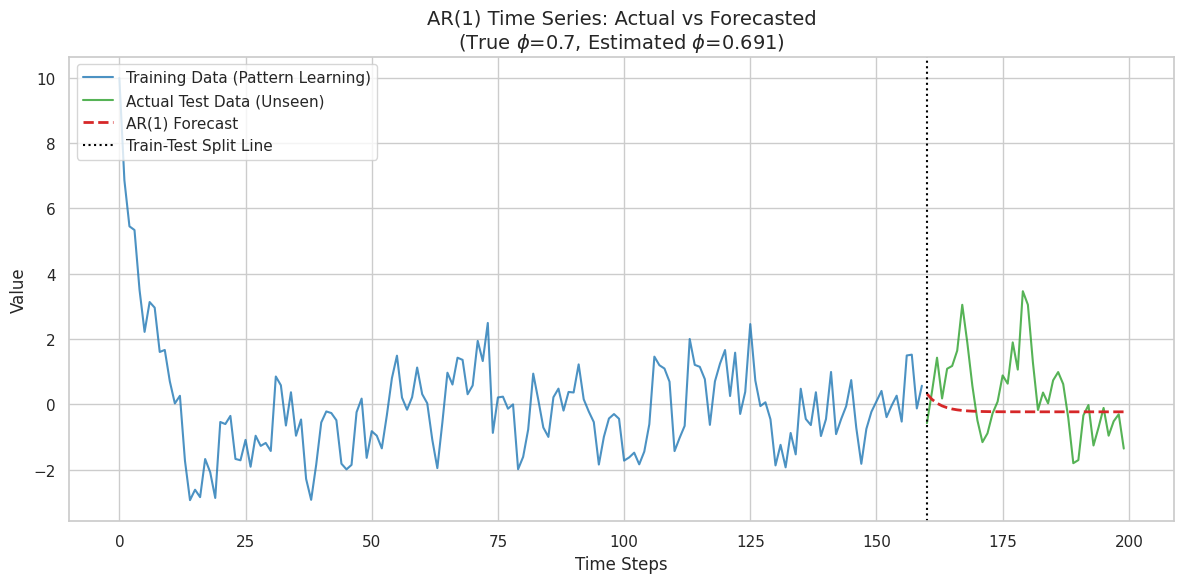

--- MODEL SUMMARY ---
                            AutoReg Model Results                             
Dep. Variable:                  Value   No. Observations:                  160
Model:                     AutoReg(1)   Log Likelihood                -214.977
Method:               Conditional MLE   S.D. of innovations              0.935
Date:                Thu, 18 Dec 2025   AIC                            435.954
Time:                        08:54:29   BIC                            445.161
Sample:                             1   HQIC                           439.693
                                  160                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0715      0.074     -0.964      0.335      -0.217       0.074
Value.L1       0.6910      0.044     15.838      0.000       0.606       0.777
                              

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Generate Synthetic AR(1) Series
np.random.seed(42)
n = 200
phi_true = 0.7
noise = np.random.normal(0, 1, n)
x = [10]  # Initial value

for t in range(1, n):
    x.append(phi_true * x[t-1] + noise[t])

data = pd.Series(x, name="Value")

# 2. Train-Test Split (80% / 20%)
train_size = int(0.8 * n)
train, test = data[:train_size], data[train_size:]

# 3. Fit AR(1) Model
# lag=1 corresponds to AR(1)
model = AutoReg(train, lags=1).fit()
phi_estimated = model.params.iloc[1] # Extract the coefficient

# 4. Forecast for Test Period
# We predict from the first test index to the last
predictions = model.predict(start=len(train), end=len(data)-1)

# 5. Advanced Visualization
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Training Data (Pattern Learning)", color='#1f77b4', alpha=0.8)
plt.plot(test.index, test, label="Actual Test Data (Unseen)", color='#2ca02c', alpha=0.8)
plt.plot(test.index, predictions, label="AR(1) Forecast", color='#d62728', linestyle='--', linewidth=2)

# Annotate the split point
plt.axvline(x=train_size, color='black', linestyle=':', label='Train-Test Split Line')
plt.title(f"AR(1) Time Series: Actual vs Forecasted\n(True $\phi$=0.7, Estimated $\phi$={phi_estimated:.3f})", fontsize=14)
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 6. Comprehensive Error Analysis
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, predictions)

print("--- MODEL SUMMARY ---")
print(model.summary())
print("\n--- PERFORMANCE METRICS ---")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3690399145.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(preds, label=f"Forecast (Estimated $\phi$: {phi_est:.3f})", color='red', linestyle='--')
/tmp/ipython-input-3690399145.py:66: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"AR(1) Forecasting (True $\phi$ = {PHI_TRUE})")


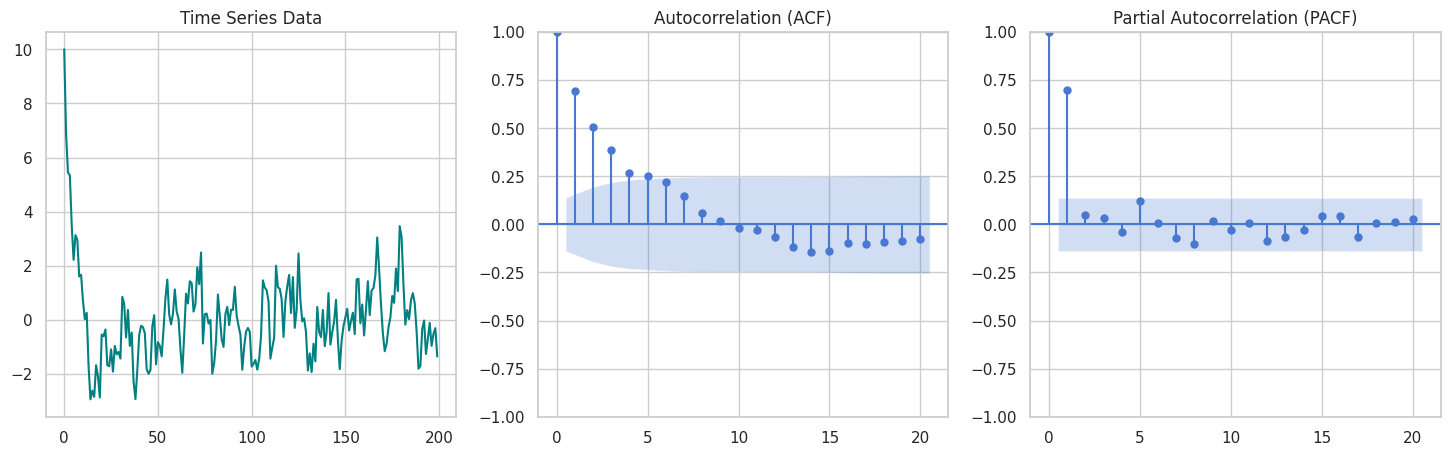

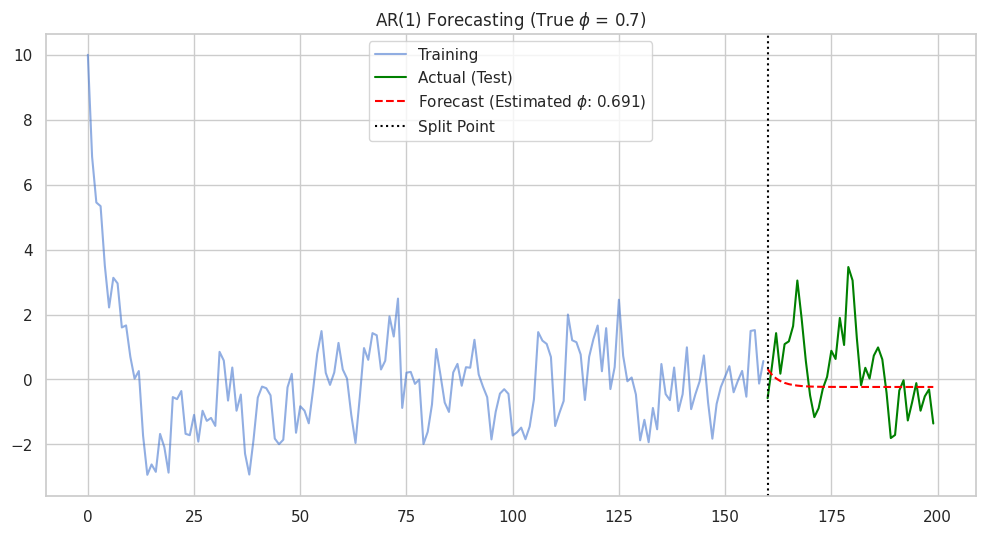

--- Statistical Metrics ---
MSE:  1.8159
RMSE: 1.3476
MAE:  1.0160
R² Score: -0.1794


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

def generate_ar_data(phi, n=200, sigma=1, seed=42):
    """Generates a synthetic AR(1) process: x_t = phi * x_{t-1} + noise."""
    np.random.seed(seed)
    noise = np.random.normal(0, sigma, n)
    x = np.zeros(n)
    x[0] = 10  # Starting value
    for t in range(1, n):
        x[t] = phi * x[t-1] + noise[t]
    return pd.Series(x, name="Value")

def plot_diagnostics(data):
    """Plots the time series along with its Autocorrelation (ACF) and Partial ACF (PACF)."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Time Series Plot
    axes[0].plot(data, color='teal')
    axes[0].set_title("Time Series Data")

    # ACF - Shows global correlation
    plot_acf(data, ax=axes[1], lags=20)
    axes[1].set_title("Autocorrelation (ACF)")

    # PACF - Shows direct correlation (Crucial for identifying AR order)
    plot_pacf(data, ax=axes[2], lags=20, method='yw') # Changed 'yule_walker' to 'yw'
    axes[2].set_title("Partial Autocorrelation (PACF)")
    plt.show()

# --- Execution ---

# 1. Data Prep
PHI_TRUE = 0.7
data = generate_ar_data(phi=PHI_TRUE)
plot_diagnostics(data)

# 2. Train-Test Split (80/20)
split = int(len(data) * 0.8)
train, test = data[:split], data[split:]

# 3. Model Fitting
# We explicitly choose lags=1 based on the PACF 'spike' at lag 1
model_fit = AutoReg(train, lags=1).fit()
phi_est = model_fit.params.iloc[1]

# 4. Forecasting & Residuals
preds = model_fit.predict(start=split, end=len(data)-1)
residuals = test - preds

# 5. Visualizing Forecast Performance
plt.figure(figsize=(12, 6))
plt.plot(train, label="Training", alpha=0.6)
plt.plot(test, label="Actual (Test)", color='green')
plt.plot(preds, label=f"Forecast (Estimated $\phi$: {phi_est:.3f})", color='red', linestyle='--')
plt.axvline(split, color='black', linestyle=':', label='Split Point')
plt.title(f"AR(1) Forecasting (True $\phi$ = {PHI_TRUE})")
plt.legend()
plt.show()

# 6. Evaluation Metrics
print(f"--- Statistical Metrics ---")
print(f"MSE:  {mean_squared_error(test, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test, preds)):.4f}")
print(f"MAE:  {mean_absolute_error(test, preds):.4f}")
print(f"R² Score: {r2_score(test, preds):.4f}")